### Problem Statement
Given the Bike Sharing dataset with hourly level information of bikes along with weather and other attributes, model a system which can predict the bike count.


In [4]:

import numpy as np
import pandas as pd

import pydotplus
from sklearn import tree
from sklearn import metrics
from sklearn import preprocessing
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split

import seaborn as sn
import matplotlib.pyplot as plt
import seaborn as sn

sn.set_style('whitegrid')
sn.set_context('talk')

params = {'legend.fontsize': 'x-large',
          'figure.figsize': (30, 10),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'}

plt.rcParams.update(params)

In [5]:
hour_df = pd.read_csv('datasets/hour.csv')
print('Shape of dataset::{}'.format(hour_df.shape))

Shape of dataset::(17379, 17)


In [6]:
hour_df.rename(columns={'instant':'rec_id',
                        'dteday':'datetime',
                        'holiday':'is_holiday',
                        'workingday':'is_workingday',
                        'weathersit':'weather_condition',
                        'hum':'humidity',
                        'mnth':'month',
                        'cnt':'total_count',
                        'hr':'hour',
                        'yr':'year'},inplace=True)

In [8]:
hour_df['datetime'] = pd.to_datetime(hour_df.datetime)

hour_df['season'] = hour_df.season.astype('category')
hour_df['is_holiday'] = hour_df.is_holiday.astype('category')
hour_df['weekday'] = hour_df.weekday.astype('category')
hour_df['weather_condition'] = hour_df.weather_condition.astype('category')
hour_df['is_workingday'] = hour_df.is_workingday.astype('category')
hour_df['month'] = hour_df.month.astype('category')
hour_df['year'] = hour_df.year.astype('category')
hour_df['hour'] = hour_df.hour.astype('category')

In [35]:
def fit_transform_ohe(df,col_name):
    
    le = preprocessing.LabelEncoder()
    le_labels  = le.fit_transform(df[col_name])
    df[col_name+'_label']  =le_labels 
    
    ohe = preprocessing.OneHotEncoder()
    feature_arr = ohe.fit_transform(df[[col_name+'_label']]).toarray()
    feature_labels = [col_name+'_'+str(cls_label) for cls_label in le.classes_]
    feature_df = pd.DataFrame(feature_arr,columns=feature_labels)
    
    return le,ohe,feature_df

def transform_ohe(df,le,ohe,col_name):
    
    col_labels = le.transform(df[col_name])
    df[col_name+'_label'] = col_labels
    
    feature_arr = ohe.fit_transform(df[[col_name+'_label']]).toarray()
    feature_labels = [col_name+'_'+str(cls_label) for cls_label in le.classes_]
    feature_df = pd.DataFrame(feature_arr,columns=feature_labels)
    
    return feature_df

In [30]:
X, X_test, y, y_test = train_test_split(hour_df.iloc[:,0:-3], hour_df.iloc[:,-1], 
                                                    test_size=0.33, random_state=42)

X.reset_index(inplace=True)
y = y.reset_index()

X_test.reset_index(inplace=True)
y_test = y_test.reset_index()

print("Training set::{}{}".format(X.shape,y.shape))
print("Testing set::{}".format(X_test.shape))

Training set::(11643, 15)(11643, 2)
Testing set::(5736, 15)


In [31]:
cat_attr_list = ['season','is_holiday',
                 'weather_condition','is_workingday',
                 'hour','weekday','month','year']
numeric_feature_cols = ['temp','humidity','windspeed','hour','weekday','month','year']
subset_cat_features =  ['season','is_holiday','weather_condition','is_workingday']

In [36]:
encoded_attr_list = []
for col in cat_attr_list:
    return_obj = fit_transform_ohe(X,col)
    encoded_attr_list.append({'label_enc':return_obj[0],
                              'ohe_enc':return_obj[1],
                              'feature_df':return_obj[2],
                              'col_name':col})

In [37]:
feature_df_list = [X[numeric_feature_cols]]
feature_df_list.extend([enc['feature_df']\
                for enc in encoded_attr_list \
                    if enc['col_name'] in subset_cat_features])

train_df_new = pd.concat(feature_df_list,axis=1)
print('Shape::{}'.format(train_df_new.shape))

Shape::(11643, 19)


In [ ]:
X = train_df_new
y = y.total_count.values.reshape(-1,1)

In [41]:
X.shape,y.shape

((11643, 19), (11643, 2))

In [42]:
dtr = DecisionTreeRegressor(max_depth=4,min_samples_split=5,max_leaf_nodes=10)

dtr.fit(X,y)

DecisionTreeRegressor(max_depth=4, max_leaf_nodes=10, min_samples_split=5)

In [43]:
dtr.score(X,y)

0.5580748481892681

In [ ]:
dot_data = tree.export_graphviz(dtr,out_file=None)
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_pdf("datasets/bikeshare.pdf")


In [62]:
# param_grid = {"criterion": ["squared_error", "absolute_error"],
#               "min_samples_split": [10, 20, 40],
#               "max_depth": [2, 6, 8],
#               "min_samples_leaf": [20, 40, 100],
#               "max_leaf_nodes": [5, 20, 100, 500, 800],
#               }


param_grid = {
    "criterion": ["squared_error", "absolute_error"],
    "min_samples_split": [20, 40],
    "max_depth": [4, 8],
    "min_samples_leaf": [20, 100],
    "max_leaf_nodes": [20, 100, 500],
}

grid_cv_dtr = GridSearchCV(
    dtr, 
    param_grid, 
    cv=3,           
    n_jobs=-1,     
    verbose=2      
)

grid_cv_dtr.fit(X, y)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=DecisionTreeRegressor(max_depth=4, max_leaf_nodes=10,
                                             min_samples_split=5),
             n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [4, 8], 'max_leaf_nodes': [20, 100, 500],
                         'min_samples_leaf': [20, 100],
                         'min_samples_split': [20, 40]},
             verbose=2)

In [ ]:
# grid_cv_dtr = GridSearchCV(dtr,param_grid,cv=5)

In [66]:
# grid_cv_dtr.fit(X,y)

In [63]:
print('R_Squared::{}'.format(grid_cv_dtr.best_score_))
print('Best Hyperparameters::\n{}'.format(grid_cv_dtr.best_params_))

R_Squared::0.782474100270219
Best Hyperparameters::
{'criterion': 'squared_error', 'max_depth': 8, 'max_leaf_nodes': 500, 'min_samples_leaf': 20, 'min_samples_split': 20}


In [64]:
df = pd.DataFrame(data=grid_cv_dtr.cv_results_)
df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.056276,0.021670,0.015053,0.003155,squared_error,4,20,20,20,"{'criterion': 'squared_error', 'max_depth': 4,...",0.567764,0.571748,0.563611,0.567708,0.003322,21
1,0.057776,0.038631,0.007013,0.000880,squared_error,4,20,20,40,"{'criterion': 'squared_error', 'max_depth': 4,...",0.567764,0.571748,0.563611,0.567708,0.003322,21
2,0.047919,0.013937,0.011568,0.001246,squared_error,4,20,100,20,"{'criterion': 'squared_error', 'max_depth': 4,...",0.567764,0.571748,0.563611,0.567708,0.003322,21
3,0.057712,0.005347,0.013895,0.002617,squared_error,4,20,100,40,"{'criterion': 'squared_error', 'max_depth': 4,...",0.567764,0.571748,0.563611,0.567708,0.003322,21
4,0.036655,0.003124,0.014450,0.008635,squared_error,4,100,20,20,"{'criterion': 'squared_error', 'max_depth': 4,...",0.567764,0.571748,0.563611,0.567708,0.003322,21


[Text(0.5, 1.0, 'Effect of Depth and Leaf Nodes on Model Performance')]

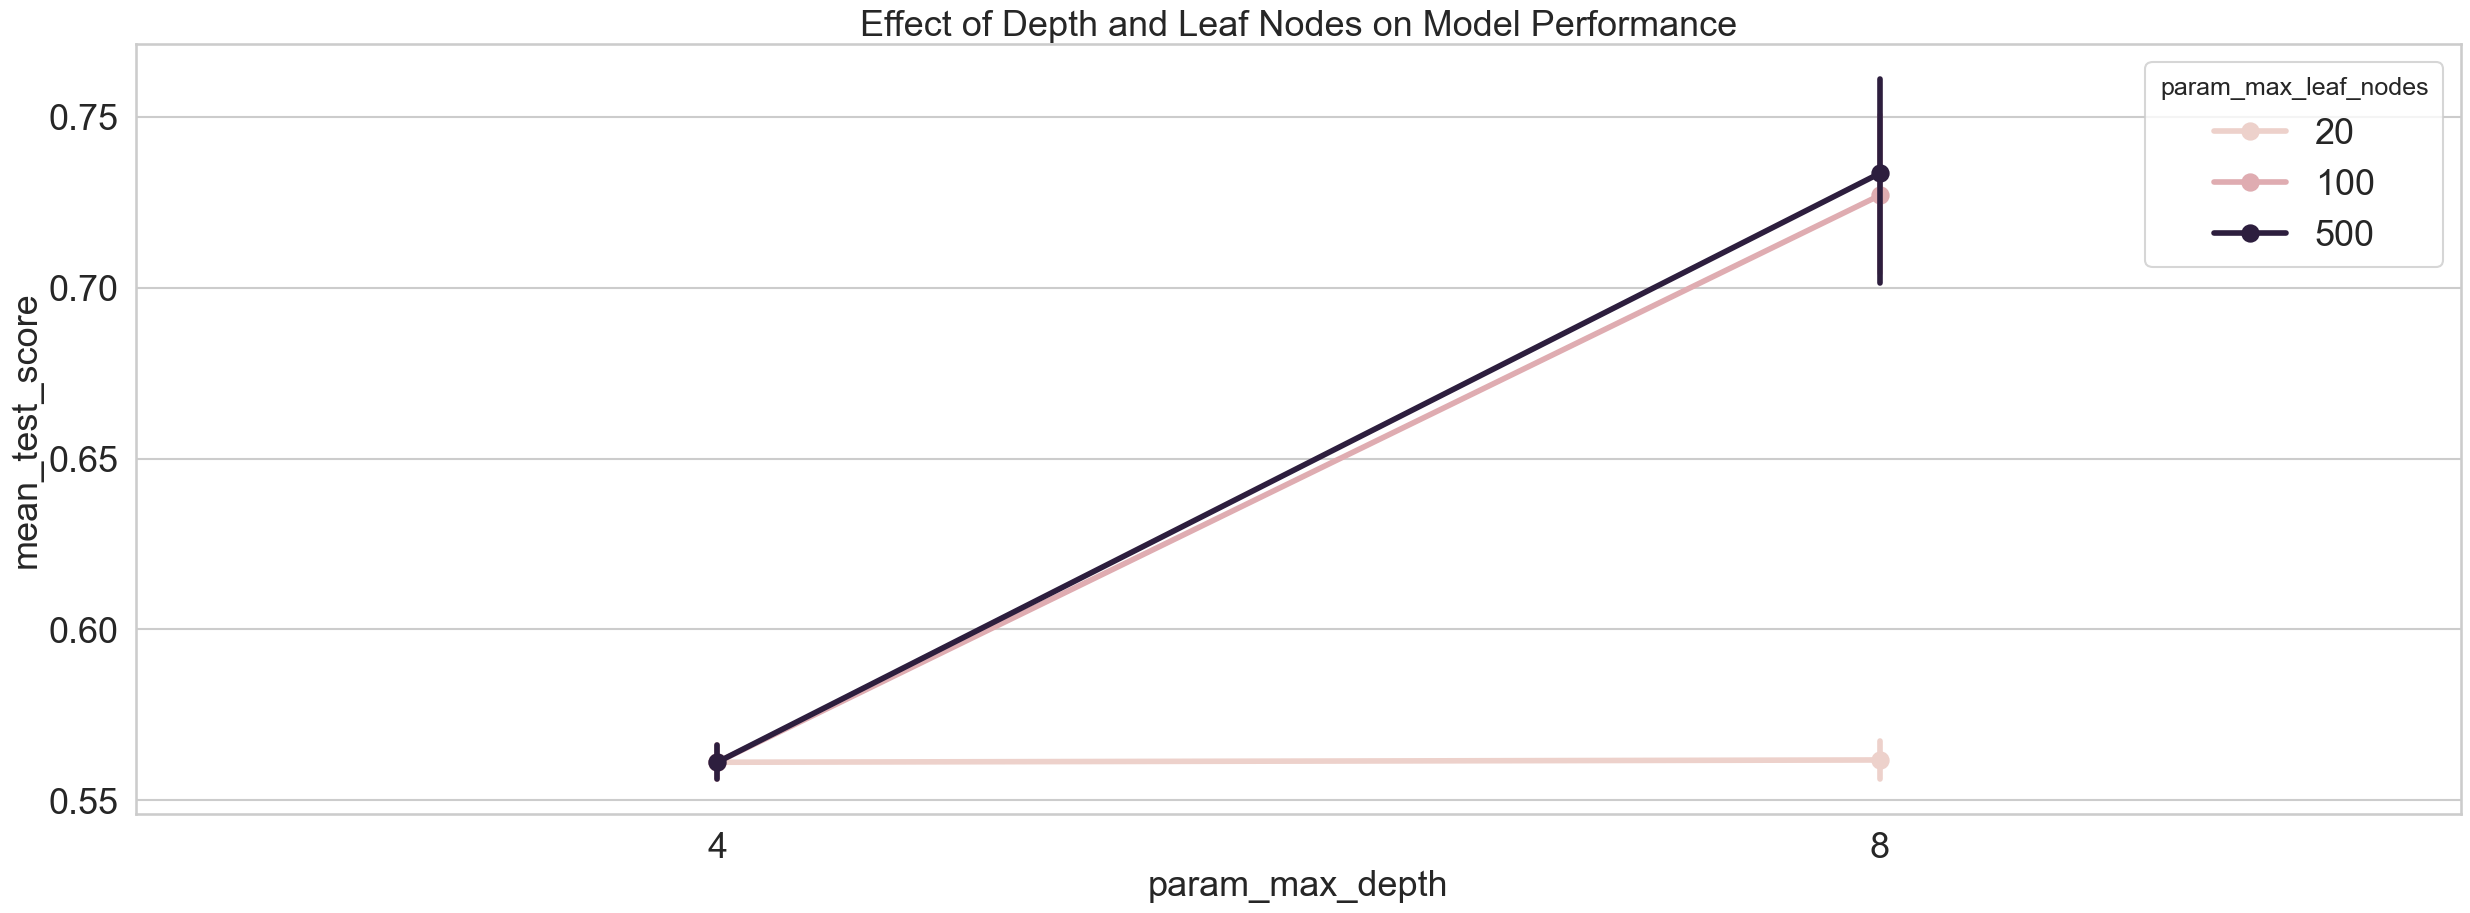

In [67]:
fig,ax = plt.subplots()
sn.pointplot(data=df[['mean_test_score',
                           'param_max_leaf_nodes',
                           'param_max_depth']],
             y='mean_test_score',x='param_max_depth',
             hue='param_max_leaf_nodes',ax=ax)
ax.set(title="Effect of Depth and Leaf Nodes on Model Performance")

In [72]:
predicted = grid_cv_dtr.best_estimator_.predict(X)

residuals = y.values - predicted 

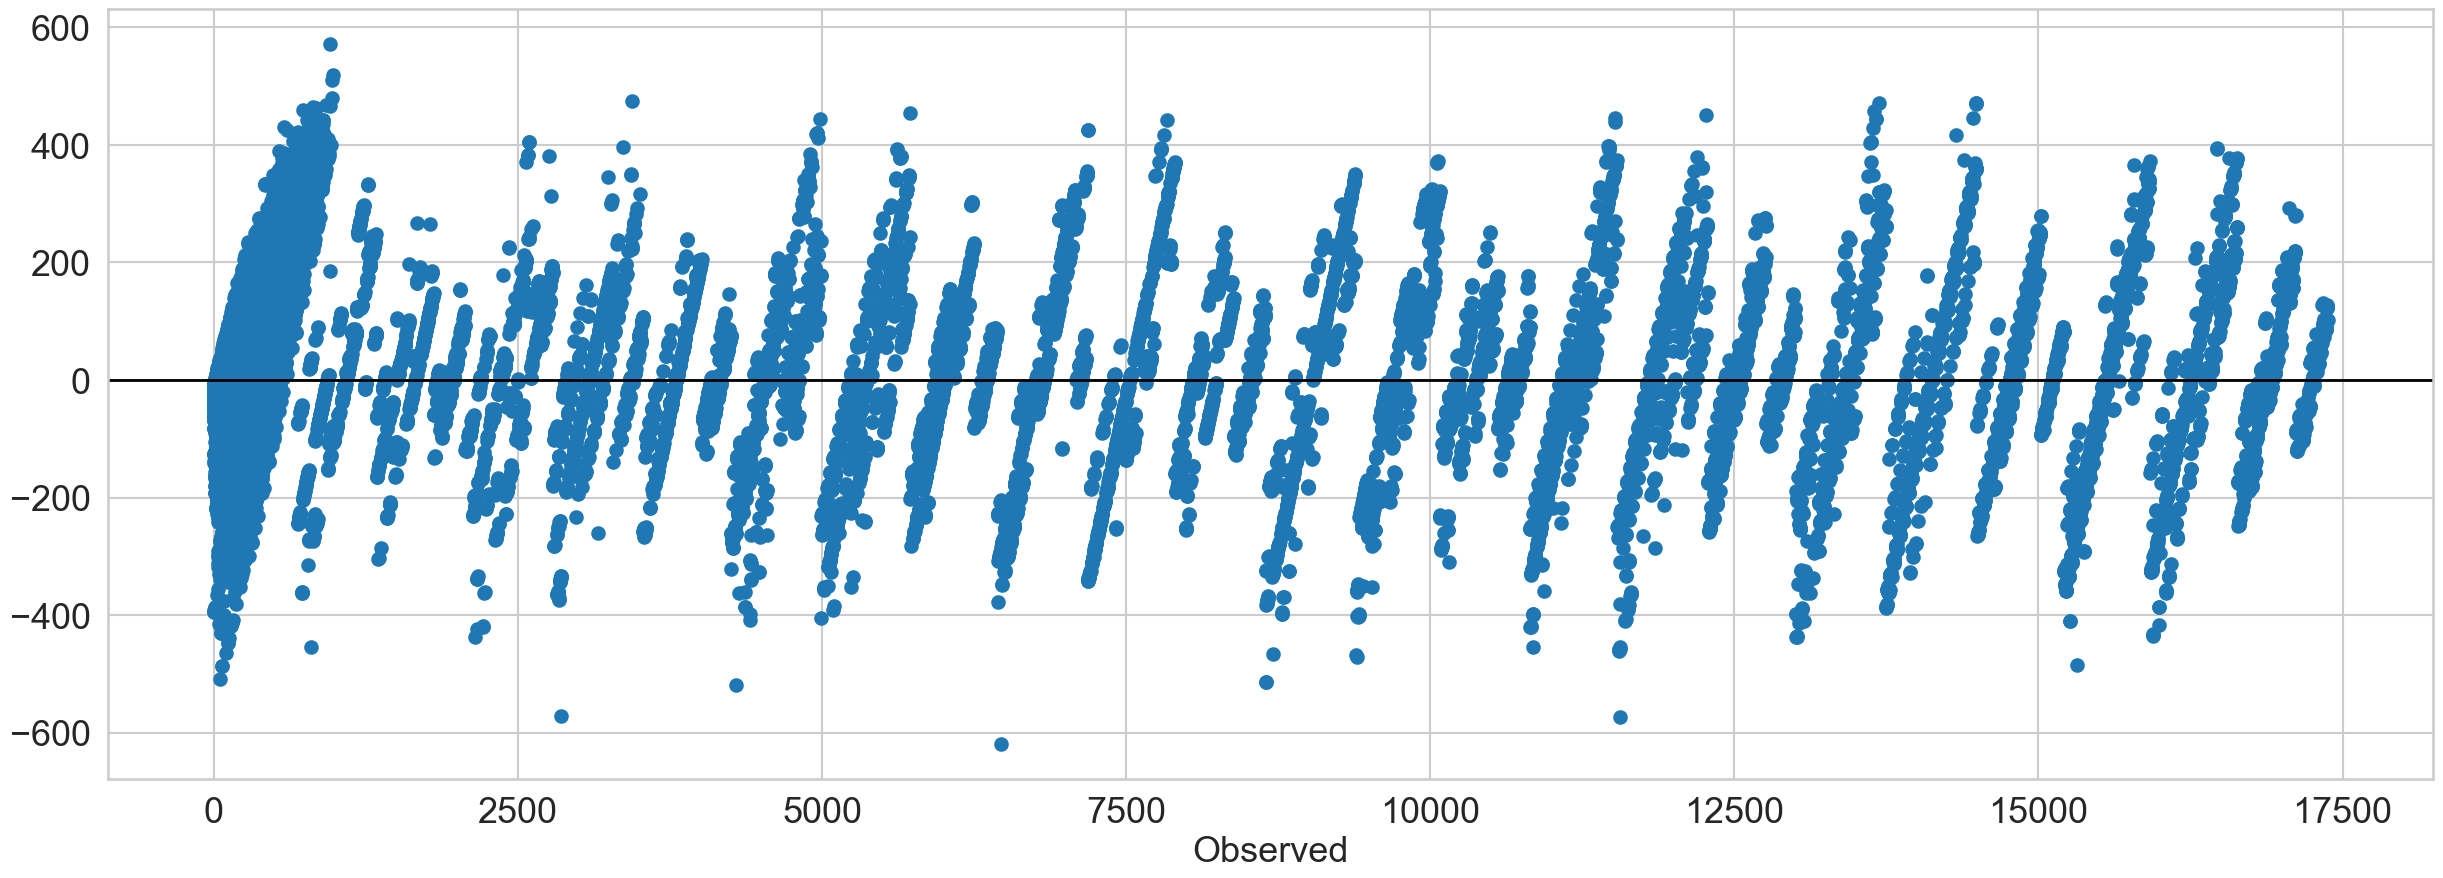

In [75]:
fig, ax = plt.subplots()
ax.scatter(y.values.flatten(),residuals)
ax.axhline(lw=2,color='black')
ax.set_xlabel('Observed')
ax.set_label('Residual')
plt.show()

In [76]:
r2_scores = cross_val_score(grid_cv_dtr.best_estimator_,X,y,cv=10)
mse_scores = cross_val_score(grid_cv_dtr.best_estimator_,X,y,cv=10,scoring='neg_mean_squared_error')

In [77]:
print('avg R-squared::{}'.format(np.mean(r2_scores)))
print('MSE::{}'.format(np.mean(mse_scores)))

avg R-squared::0.7938360773966964
MSE::-21236.043399091654


In [84]:
best_dtr_model = grid_cv_dtr.best_estimator_

In [79]:
test_encoded_attr_list = []
for enc in encoded_attr_list:
    col_name = enc['col_name']
    le = enc['label_enc']
    ohe = enc['ohe_enc']
    test_encoded_attr_list.append({'feature_df':transform_ohe(X_test,le,ohe,col_name),
                                   'col_name':col_name})
    
test_feature_df_list = [X_test[numeric_feature_cols]]
test_feature_df_list.extend([enc['feature_df'] for enc in test_encoded_attr_list if enc['col_name'] in subset_cat_features])

test_df_new = pd.concat(test_feature_df_list,axis=1)
print('Shape::{}'.format(test_df_new.shape))

Shape::(5736, 19)


In [ ]:
X_test = test_df_new
y_test = y_test.total_count.values.reshape(-1,1)

In [ ]:
y_pred = best_dtr_model.predict(X_test)
residuals = y_test.flatten()-y_pred

In [ ]:
r2_scores = best_dtr_model.score(X_test,y_test)
print('R-squared::{}'.format(r2_scores))
print('MSE:%.2f'
      % metrics.mean_squared_error(y_test,y_pred))

In [ ]:
fig, ax = plt.subplots()
ax.scatter(y_test.flatten(), residuals)
ax.axhline(lw=2,color='black')
ax.set_xlabel('Observed')
ax.set_ylabel('Residual')
plt.show()

r2_score = grid_cv_dtr.best_estimator_.score(X_test,y_test)